In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('ggplot')

# **IMPORT DATASET**

In [ ]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


# **DATA EXPLORATION**

In [ ]:
df.shape

(768, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [ ]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# **EDA**

> Tambahkan blockquote



In [ ]:
features = df.columns[:-1]
target = df.columns[-1]

print('Features:', features, 'Target:', target)

Features: Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object') Target: Outcome


In [ ]:
df.nunique()

,0
Pregnancies,17
Glucose,136
BloodPressure,47
SkinThickness,51
Insulin,186
BMI,248
DiabetesPedigreeFunction,517
Age,52
Outcome,2


In [ ]:
DPF_range = df['DiabetesPedigreeFunction'].max() / df['DiabetesPedigreeFunction'].median()
print(DPF_range)

6.496644295302013


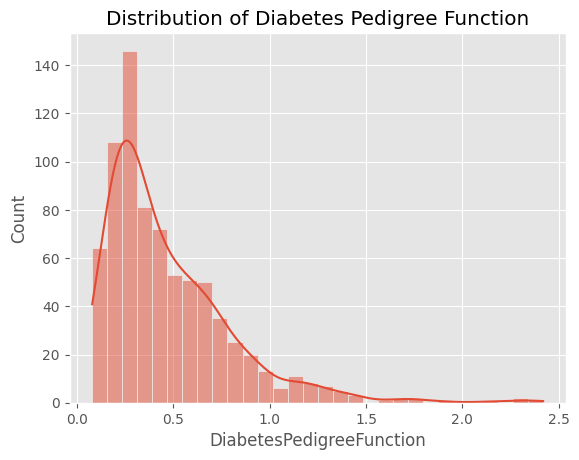

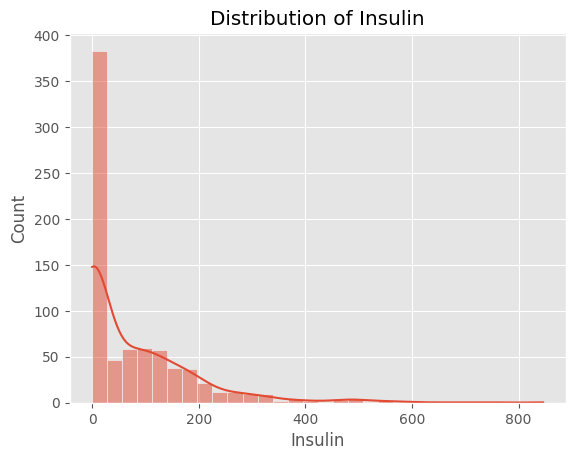

In [ ]:
sns.histplot(data=df, x='DiabetesPedigreeFunction', bins=30, kde=True)
plt.title('Distribution of Diabetes Pedigree Function')
plt.show()

sns.histplot(data=df, x='Insulin', bins=30, kde=True)
plt.title('Distribution of Insulin')
plt.show()

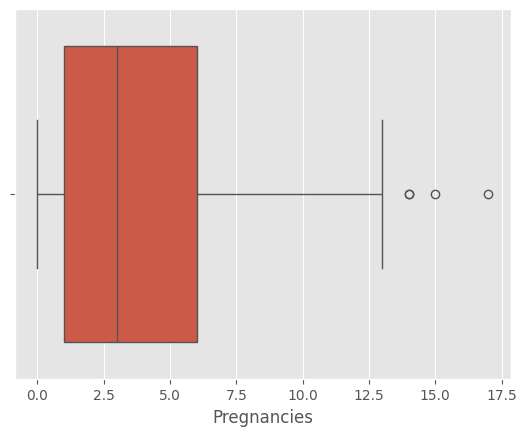

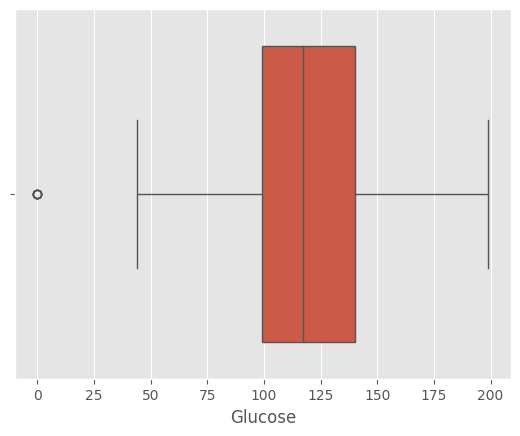

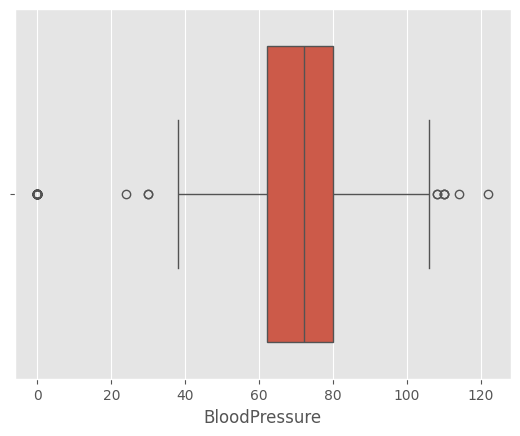

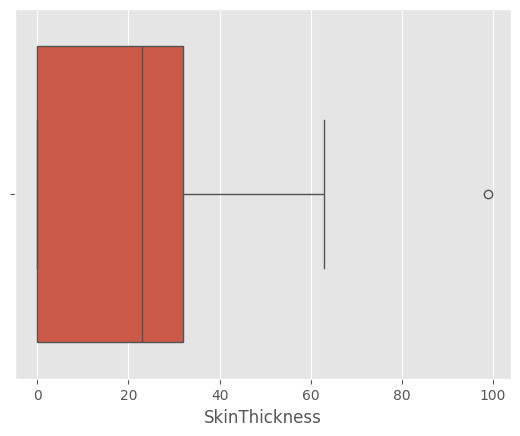

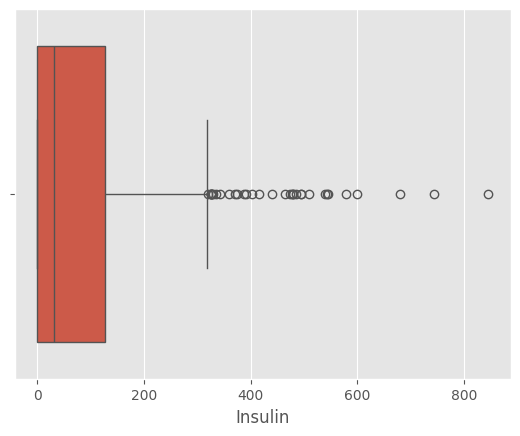

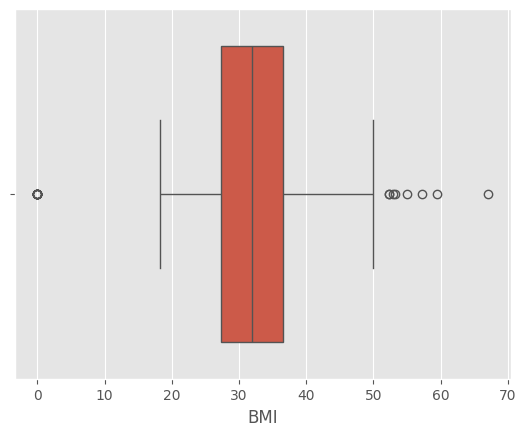

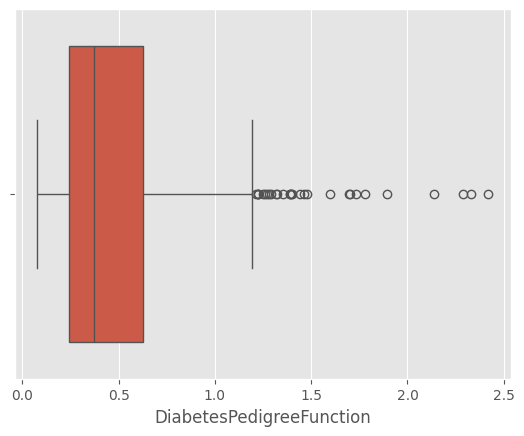

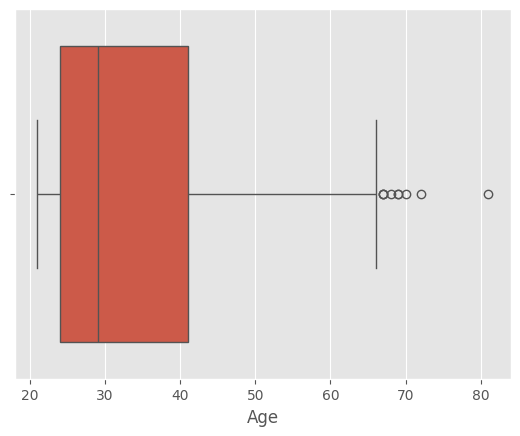

In [ ]:
for i in features:
  sns.boxplot(data=df, x=i)
  plt.show()

In [ ]:
df[['DiabetesPedigreeFunction','Insulin']].skew()

,0
DiabetesPedigreeFunction,1.919911
Insulin,2.272251


The skewness analysis shows that Insulin (2.27) and DiabetesPedigreeFunction (1.92) both exhibit high positive skewness (skewness > 1). This indicates that the majority of the data points are concentrated in the lower range, while a small number of extreme values extend the distribution to the right. Such distributions suggest the presence of significant outliers and non-normality, which may negatively affect the performance of machine learning models that assume normally distributed data.

In [ ]:
for col in [['Glucose','Insulin','BMI','BloodPressure','SkinThickness','DiabetesPedigreeFunction']]:
  print(col, (df[col] == 0).sum())

['Glucose', 'Insulin', 'BMI', 'BloodPressure', 'SkinThickness', 'DiabetesPedigreeFunction'] Glucose                       5
Insulin                     374
BMI                          11
BloodPressure                35
SkinThickness               227
DiabetesPedigreeFunction      0
dtype: int64


In [ ]:
(df['Insulin'] == 0).sum()

np.int64(374)

# **DATA PREPROCESSING**

**Transformation**

In [ ]:
from sklearn.model_selection import train_test_split
X = df[features]
Y = df[target]
X,Y
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, stratify=Y, random_state=42)
X_train.shape, X_test.shape

((614, 8), (154, 8))

In [ ]:
X_train['DiabetesPedigreeFunction'] = np.log1p(X_train['DiabetesPedigreeFunction'])
X_test['DiabetesPedigreeFunction'] = np.log1p(X_test['DiabetesPedigreeFunction'])

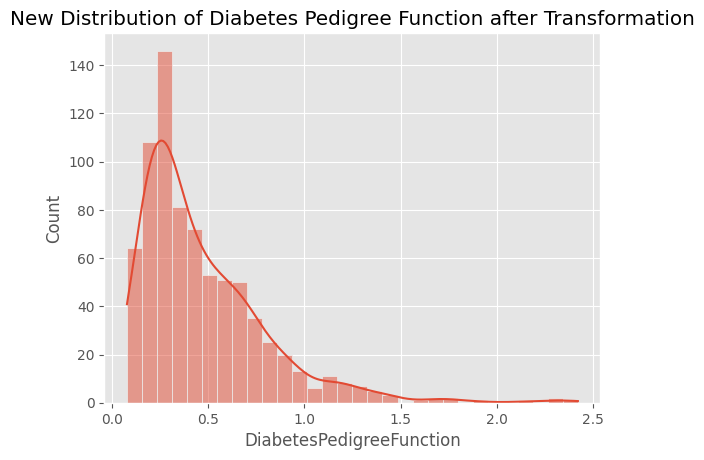

In [ ]:
sns.histplot(data=df, x='DiabetesPedigreeFunction', bins=30, kde=True)
plt.title('New Distribution of Diabetes Pedigree Function after Transformation')
plt.show()

**HANDLING THE INVALID VALUES**

In [ ]:
col_invalid_val = ['Glucose','Insulin','BMI','BloodPressure','SkinThickness']

In [ ]:
#CHECKING AGAIN
(df[col_invalid_val] == 0).sum()

,0
Glucose,5
Insulin,374
BMI,11
BloodPressure,35
SkinThickness,227


In [ ]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
X_train[col_invalid_val] = X_train[col_invalid_val].replace(0, np.nan)
X_test[col_invalid_val] = X_test[col_invalid_val].replace(0, np.nan)

In [ ]:
from sklearn.impute import KNNImputer
impute = KNNImputer()
X_train[col_invalid_val] = impute.fit_transform(X_train[col_invalid_val])
X_test[col_invalid_val] = impute.transform(X_test[col_invalid_val])
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**OUTLIERS TREATMENT**

In [ ]:
def whisker(col):
    q1, q3 = np.percentile(col, [25, 75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

In [ ]:
# SkinThickness and Insulin
for i in ['Insulin', 'SkinThickness']:
    lower, upper = whisker(X_train[i])
    X_train[i] = np.clip(X_train[i], lower, upper)
    X_test[i] = np.clip(X_test[i], lower, upper)

# **TRAINING**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

model = make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced'))
model.fit(X_train, Y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(class_weight='balanced'))])

**MODEL EVALUATION**

In [ ]:
from sklearn.metrics import accuracy_score
classifier_predict = model.predict(X_train)
accuracy = accuracy_score(Y_train, classifier_predict)
print("The accuracy score is ",accuracy)

The accuracy score is  0.8127035830618893


**TUNING**

In [ ]:
pipeline = make_pipeline(StandardScaler(), SVC(class_weight='balanced'))

# Define the parameter grid
param_grid = {
    'svc__C': [0.1, 1, 10],  # Regularization parameter
    'svc__gamma': [1, 0.1, 0.01, 0.001], # Kernel coefficient
    'svc__kernel': ['rbf', 'linear', 'poly'] # Kernel type
}

# Setup GridSearchCV
grid = GridSearchCV(pipeline, param_grid, refit=True, verbose=2, cv=5, scoring='accuracy')

# Fit the model
grid.fit(X_train, Y_train)

# Print best parameters
print("Best parameters found: ", grid.best_params_)
print("Best cross-validation accuracy: ", grid.best_score_)

# Evaluate on test set
from sklearn.metrics import accuracy_score
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(Y_test, y_pred)
print("Test set accuracy: ", test_accuracy)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END ..........svc__C=0.1, svc__gamma=1, svc__kernel=rbf; total time=   0.0s
[CV] END ..........svc__C=0.1, svc__gamma=1, svc__kernel=rbf; total time=   0.0s
[CV] END ..........svc__C=0.1, svc__gamma=1, svc__kernel=rbf; total time=   0.0s
[CV] END ..........svc__C=0.1, svc__gamma=1, svc__kernel=rbf; total time=   0.0s
[CV] END ..........svc__C=0.1, svc__gamma=1, svc__kernel=rbf; total time=   0.0s
[CV] END .......svc__C=0.1, svc__gamma=1, svc__kernel=linear; total time=   0.0s
[CV] END .......svc__C=0.1, svc__gamma=1, svc__kernel=linear; total time=   0.0s
[CV] END .......svc__C=0.1, svc__gamma=1, svc__kernel=linear; total time=   0.0s
[CV] END .......svc__C=0.1, svc__gamma=1, svc__kernel=linear; total time=   0.0s
[CV] END .......svc__C=0.1, svc__gamma=1, svc__kernel=linear; total time=   0.0s
[CV] END .........svc__C=0.1, svc__gamma=1, svc__kernel=poly; total time=   0.1s
[CV] END .........svc__C=0.1, svc__gamma=1, svc

**EVALUATION**

In [ ]:
model_after_tuning = make_pipeline(StandardScaler(), SVC(kernel='poly', C=0.1, gamma=0.1, class_weight='balanced'))
model_after_tuning.fit(X_train, Y_train)
classifier_predict_2 = model_after_tuning.predict(X_train)
accuracy_2 = accuracy_score(Y_train, classifier_predict_2)
print("The accuracy score is ",accuracy_2)

The accuracy score is  0.7801302931596091


In [ ]:
classifier_test_predict = model_after_tuning.predict(X_test)
accuracy_test = accuracy_score(Y_test, classifier_test_predict)
print("The accuracy score is ",accuracy_test)

The accuracy score is  0.7337662337662337


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

print("="*50)
print("MODEL 1: RANDOM FOREST")
print("="*50)

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [2, 3, 4],
    'rf__min_samples_split': [10, 20],
    'rf__min_samples_leaf': [5, 10, 15],
    'rf__max_features': ['sqrt', 'log2']
}

# Gunakan GridSearchCV (Cross-validation 5 fold)
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, Y_train)

print("Parameter Terbaik RF:", rf_grid.best_params_)

# Evaluasi Random Forest
rf_best = rf_grid.best_estimator_
rf_train_acc = accuracy_score(Y_train, rf_best.predict(X_train))
rf_test_acc = accuracy_score(Y_test, rf_best.predict(X_test))

print(f"Akurasi Training (RF) : {rf_train_acc:.4f}")
print(f"Akurasi Testing (RF)  : {rf_test_acc:.4f}")
# Jarak antara Training dan Testing yang kecil menandakan TIDAK OVERFIT


print("\n" + "="*50)
print("MODEL 2: GRADIENT BOOSTING (Alternative)")
print("="*50)

gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    'gb__n_estimators': [50, 100],
    'gb__learning_rate': [0.01, 0.05],
    'gb__max_depth': [1, 2],               # Gunakan weak learners (hanya 1-2 kedalaman)
    'gb__subsample': [0.7, 0.8]
}

gb_grid = GridSearchCV(gb_pipeline, gb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gb_grid.fit(X_train, Y_train)

print("Parameter Terbaik GB:", gb_grid.best_params_)

# Evaluasi Gradient Boosting
gb_best = gb_grid.best_estimator_
gb_train_acc = accuracy_score(Y_train, gb_best.predict(X_train))
gb_test_acc = accuracy_score(Y_test, gb_best.predict(X_test))

print(f"Akurasi Training (GB) : {gb_train_acc:.4f}")
print(f"Akurasi Testing (GB)  : {gb_test_acc:.4f}")

MODEL 1: RANDOM FOREST
Parameter Terbaik RF: {'rf__max_depth': 2, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 15, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}
Akurasi Training (RF) : 0.7948
Akurasi Testing (RF)  : 0.7273

MODEL 2: GRADIENT BOOSTING (Alternative)
Parameter Terbaik GB: {'gb__learning_rate': 0.05, 'gb__max_depth': 2, 'gb__n_estimators': 100, 'gb__subsample': 0.7}
Akurasi Training (GB) : 0.8339
Akurasi Testing (GB)  : 0.7338


In [ ]:
df[df[target] == 1].head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
2,8,183,64,0,0,23.3,0.672,32,1
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1


In [ ]:
import numpy as np

input_data = (2,197,70,45,543,30.5,0.158,53)

input_data_arr = np.asarray(input_data).reshape(1, -1)

final_model_prediction = model_after_tuning.predict(input_data_arr)

if final_model_prediction[0] == 0:
    print("The person is not diabetic")
else:
    print("The person is diabetic")


The person is diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
